# 03b-01 - Photographs and Metadata

You see what the software, OpenDroneMap, knew before it looked at a single pixel: the camera, where each photograph was taken, and which photographs overlap.

We start with the whole flight on the map. Then we read one photograph's file, follow the positions and headings of all of them, draw every footprint to predict which pairs overlap, and hold the prediction against the pairs the software matched. At the end you change one number.

This notebook reads the flight named in `data/flight.json`. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that the next pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sfm_tools as sfm
from matplotlib.collections import LineCollection

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight, choices = sfm.load_flight("data/flight.json")
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at "
      f"{flight['altitude_agl_m']} m, {flight['n_photos']} photographs")

the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs


## The flight on the map

The cell reads the software's count of photographs per ground cell and draws it with the field's outline and every photograph's position.

85 photographs   reference 85
a cell was seen by 2 to 13 photographs, half of them by 5 or more


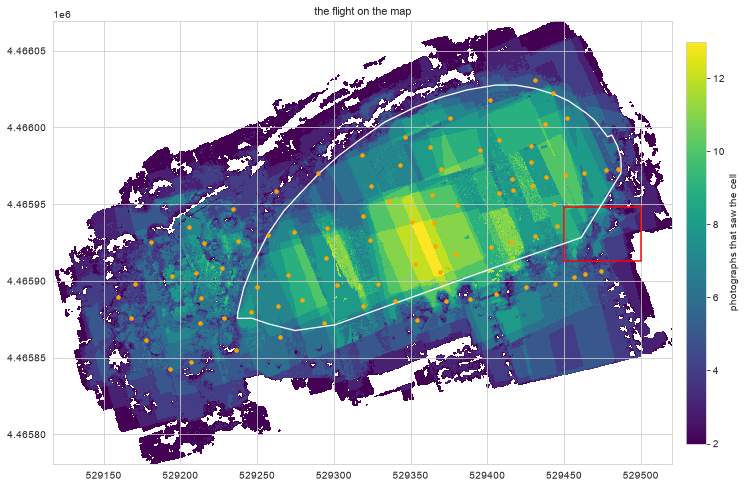

In [2]:
count, transform, crs, cell_m = sfm.read_raster("data/overlap_count.tif")
field = gpd.read_file("data/site.gpkg", layer="site").to_crs(choices["crs"])
photos = pd.read_csv("data/photos.csv")
positions = photos[["easting", "northing"]].to_numpy()
low, mid, high = np.nanpercentile(count, [0, 50, 100])
print(f"{len(photos)} photographs   reference {reference['block']['shots']}")
print(f"a cell was seen by {low:.0f} to {high:.0f} photographs, half of them by {mid:.0f} or more")
fig, ax = plt.subplots(figsize=(12, 8))
sfm.show_grid(ax, count, transform, label="photographs that saw the cell", outline=field,
              points=positions, window=choices["window"]["bounds"], title="the flight on the map")

Every orange dot is one photograph, at the position the drone's satellite receiver wrote into its file. The colour under it says how many photographs saw that piece of ground. Two is the fewest that give a height, because a height needs two views, and the software kept no cell with fewer. Look where the count is high and where it thins out towards the edge. The red rectangle is the window of every later notebook, a footpath junction and the corner of a flat roof.

## What the software read from one photograph

The cell reads what the software took from one photograph's file, the one every later notebook calls photograph a, and shows the picture.

DJI FC3682, 4000 by 3000 pixels, a 6.72 mm lens, 24 mm on a 35 mm frame
from the 35 mm equivalent   2666.7 px   reference 2666.7
from the lens and the pixel   2800.0 px   reference 2800.0


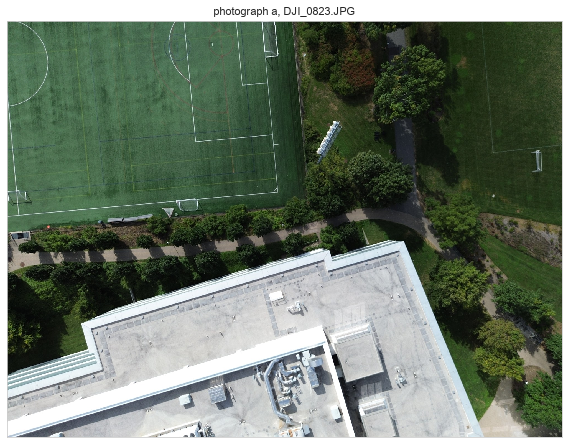

In [3]:
exif = pd.read_csv("data/exif_opensfm.csv").set_index("image")
soft = exif.loc[choices["photos"]["a"]["name"]]
own = photos.set_index("file").loc[soft.name]
cal = reference["block"]["calibration"]
camera = f"{soft['make']} {soft['model']}, {soft['width']} by {soft['height']} pixels"
f_equivalent = soft["focal_ratio"] * soft["width"]
f_lens = own["focal_mm"] * 1000 / sfm.PIXEL_UM
print(f"{camera}, a {own['focal_mm']} mm lens, {own['focal_35mm_equivalent']} mm on a 35 mm frame")
print(f"from the 35 mm equivalent   {f_equivalent:.1f} px   reference {cal['focal_prior_px']}")
print(f"from the lens and the pixel   {f_lens:.1f} px   reference {cal['focal_from_exif_px']}")
fig, ax = plt.subplots(figsize=(10, 7.5))
sfm.show_image(ax, sfm.read_image("data/photo_a.jpg"), title=f"photograph a, {soft.name}")

The first line names the camera, its frame in pixels and the lens. Next, two focal lengths for one lens. One comes from the 35 mm equivalent, the focal length this lens would have on a film frame. The other comes from the focal length in millimetres and the width of one pixel on the sensor. They differ by a few percent. Neither is the truth. Both are starting guesses, and 03b-04 shows which one the flight moved towards. The software assumed that every camera looked straight down.

## Position, height and heading of every photograph

The cell reads where each photograph was taken, how high the drone was and which way its nose pointed, and draws the path of the flight.

height above the take-off point   76.8 to 83.8 m
heading of the aircraft   -114 to 166 degrees from north
from one photograph to the next   22 m along the path, typically


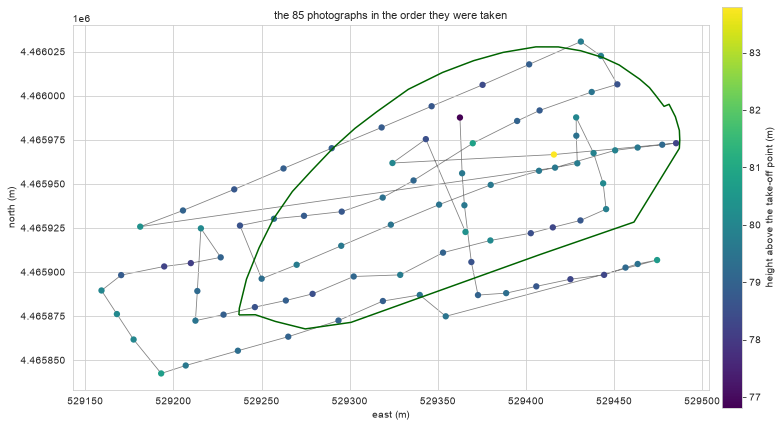

In [4]:
height = photos["rel_alt_m"]
heading = photos["flight_yaw_deg"]
step_m = photos["metres_from_previous"].median()
xyz = photos[["easting", "northing", "rel_alt_m"]].to_numpy()
print(f"height above the take-off point   {height.min():.1f} to {height.max():.1f} m")
print(f"heading of the aircraft   {heading.min():.0f} to {heading.max():.0f} degrees from north")
print(f"from one photograph to the next   {step_m:.0f} m along the path, typically")
fig, ax = plt.subplots(figsize=(12, 8))
field.boundary.plot(ax=ax, color="darkgreen")
ax.plot(xyz[:, 0], xyz[:, 1], color="grey", linewidth=0.8, zorder=0)
sfm.show_cloud(ax, xyz, size=40, label="height above the take-off point (m)",
               title=f"the {len(photos)} photographs in the order they were taken")

The grey line joins the photographs in the order they were taken. You flew the drone by hand, so the line wanders across the field rather than running in neat strips. The colour is the height above the take-off point, about 80 metres throughout. The heading is the direction the aircraft's nose pointed, in degrees from north, and it changed at every turn. Read how far apart neighbouring photographs are. The footprints of the next section need exactly these three things for every photograph.

## Footprints and predicted overlap

The cell draws the rectangle each photograph covered on the ground and counts the pairs whose rectangles overlap, before any pixel is read.

1642 pairs of footprints that touch   reference 1642
1048 pairs over a fifth   reference 1048
407 pairs over a half   reference 407


Text(0.5, 1.0, '85 footprints and the 1048 pairs predicted over a fifth')

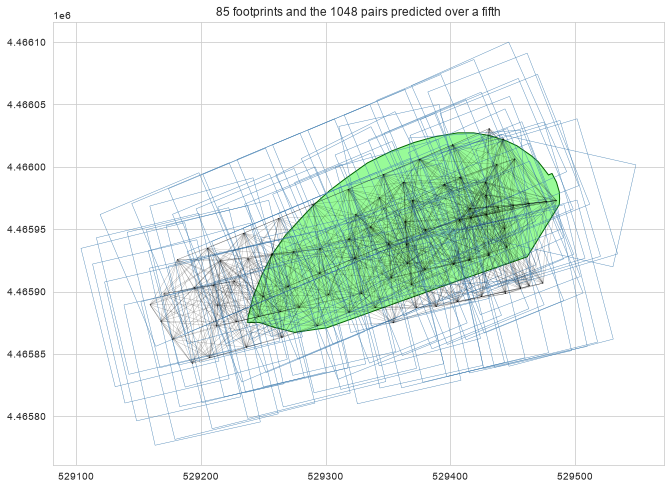

In [5]:
polygons = sfm.footprints(photos, choices)
shares = pd.Series(sfm.overlap_shares(polygons))
predicted = reference["overlap"]["predicted_pairs"]
print(f"{len(shares)} pairs of footprints that touch   reference {predicted['any']}")
print(f"{(shares >= 0.2).sum()} pairs over a fifth   reference {predicted['at_least_20_percent']}")
print(f"{(shares >= 0.5).sum()} pairs over a half   reference {predicted['at_least_50_percent']}")
segments = positions[np.array(shares[shares >= 0.2].index.tolist())]
fig, ax = plt.subplots(figsize=(12, 8))
field.plot(ax=ax, facecolor="palegreen", edgecolor="darkgreen")
gpd.GeoSeries(polygons, crs=choices["crs"]).boundary.plot(ax=ax, color="steelblue", linewidth=0.4)
ax.add_collection(LineCollection(segments, colors="black", linewidths=0.3, alpha=0.4))
ax.set_title(f"{len(polygons)} footprints and the {len(segments)} pairs predicted over a fifth")

A footprint is the rectangle one photograph covers on the ground. It comes from the height and the heading in the file, and from the camera. Two footprints that share a fifth or more of their area have enough common ground to match, and the thin lines join those pairs. Count the pairs at a fifth and at a half. Short lines join neighbours along the path, long lines join photographs from different passes. This is a prediction made before any pixel was read. The next section checks it.

## The pairs the software matched

The cell reads the pairs in which the software found matches and draws each as a line between the two positions, coloured by the number of matches.

672 matched pairs   reference 672
659 of them predicted   reference 659


Text(0.5, 1.0, 'the 672 pairs the software matched')

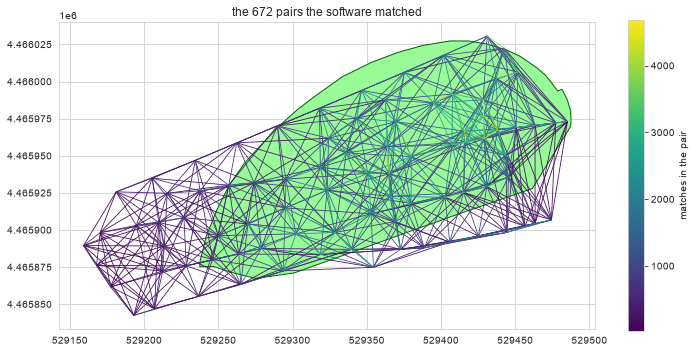

In [6]:
pairs = pd.read_csv("data/pairs.csv")
matched = pairs[pairs["matches"] > 0].sort_values("matches")
order = pd.Series(range(len(photos)), index=photos["file"])
ij = list(zip(order[matched["image_a"]], order[matched["image_b"]]))
among = len(set(ij) & set(shares[shares >= 0.2].index))
print(f"{len(matched)} matched pairs   reference {reference['overlap']['matched_pairs']}")
print(f"{among} of them predicted   reference {reference['overlap']['matched_among_predicted_20']}")
fig, ax = plt.subplots(figsize=(12, 8))
field.plot(ax=ax, facecolor="palegreen", edgecolor="darkgreen")
lines = LineCollection(positions[np.array(ij)], array=matched["matches"], lw=0.8, cmap="viridis")
fig.colorbar(ax.add_collection(lines), ax=ax, shrink=0.7, label="matches in the pair")
ax.set_title(f"the {len(matched)} pairs the software matched")

Now the real result. A match is one spot on the ground found in both photographs of a pair. Each line joins a pair with matches, and its colour says how many. Short bright lines are neighbours on one pass. Long dark lines cross the field with a few hundred matches. Read the second number against the first. Nearly every matched pair was one the rectangles predicted, so the positions and headings in the files were good enough to tell the software where to look.

## Your turn

The footprints predicted the pairs at a fifth of their area. Raise the bar to a half and count again how many of the software's matched pairs the footprints had predicted. Run the cell as it is, then change the marked value and run it again.

What does a matched pair that the footprints never predicted tell you about the prediction, or about the positions and headings in the files? Write your answer in one or two sentences. The answer comes in Friday's post, not in the kit.

In [7]:
THRESHOLD = 0.2  # change me: 0.5
predicted_pairs = set(shares[shares >= THRESHOLD].index)
print(f"{len(predicted_pairs)} pairs predicted at a share of {THRESHOLD} or more")
print(f"{len(predicted_pairs & set(ij))} of the {len(ij)} matched pairs were among them")

1048 pairs predicted at a share of 0.2 or more
659 of the 672 matched pairs were among them


## Check your understanding

1. Two focal lengths came out of one file. Where does each come from, and why is neither the one the flight ends with?
2. Why does the software's count of photographs per cell start at two, and what does a count of two mean for a height?
3. What is a footprint, and which three numbers from a photograph's file does it take?
4. Why can the overlap of two photographs be predicted before a pixel is read, and why is that prediction still worth checking against the matches?

## Where we are

You have read what the software knew before it looked at a pixel: the camera with two guesses for its focal length, the position, height and heading of every photograph, and the pairs whose footprints overlap. You now know that these are starting guesses from the files, and that the overlap they predict agrees closely with the pairs the software later matched. In 03b-02 we open one photograph and find the spots the software can match.

## Further resources

Nothing in this course requires anything below.

- OpenDroneMap documentation on the receiver's accuracy, the matched neighbours and the camera database, OpenDroneMap Project, 2026, https://docs.opendronemap.org/arguments/
- OpenSfM documentation on the camera models and the normalised image coordinates, Mapillary, 2026, https://opensfm.org/docs/
- Computer Vision, Algorithms and Applications, second edition, chapter 2 on image formation, Richard Szeliski, Springer, 2022, https://szeliski.org/Book/
- Elements of Photogrammetry with Applications in GIS, fourth edition, Paul Wolf, Bon Dewitt and Benjamin Wilkinson, McGraw-Hill, 2014

The photographs, the software's files and the products are the course's own flight, published under CC BY 4.0. The outline of Poe Field and the buildings are an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright